# <font color="maroon">**SOIL QUALITY PREDICTION ANALYSIS**
<font color="maroon">Soil quality prediction analysis involves using data-driven**ML  models** to estimate soil properties and health indicators without extensive, costly field sampling. This approach is a key component of precision agriculture, helping farmers and environmental managers make informed decisions.

# <font color="green">	**CLASSIFICATION MODELS**
1.  Logistic regression
2.  Decision Tree Classification
3.  Random Forest classification
4.  Adaboost Classifier
5.  Gradient Boost Classifier
6.  KNN Classifier
7.  Gaussian NB Classifier



In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv(r"/content/drive/MyDrive/soil pollution prediction[classification].csv")
data

,Case_ID,Date_Reported,Region,Country,Pollutant_Type,Pollutant_Concentration_mg_kg,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,...,Soil_Organic_Matter_%,Disease_Type,Disease_Severity,Health_Symptoms,Age_Group_Affected,Gender_Most_Affected,Mitigation_Measure,Case_Resolved,Follow_Up_Required,Soil_Quality
0,CASE_100000,12-09-2024,Africa,Pakistan,Lead,78.04,8.30,35.6,64.9,62.4,...,1.98,Gastrointestinal Disease,Moderate,Breathing Difficulty,Adults,Male,Government Regulation,No,Yes,Moderate
1,CASE_100001,01-01-2024,Africa,Germany,Lead,16.33,7.96,31.0,73.1,8.2,...,9.71,Cancer,Mild,Breathing Difficulty,Elderly,Both,Community Awareness,Yes,No,Moderate
2,CASE_100002,24-02-2025,Europe,Germany,Lead,167.33,5.35,16.4,33.8,121.7,...,5.49,Gastrointestinal Disease,Severe,Nausea,Children,Both,Soil Remediation,Yes,No,Poor
3,CASE_100003,24-09-2024,Asia,USA,Lead,89.23,5.66,31.4,30.5,116.9,...,3.98,Neurological Disorder,Severe,Fatigue,Adults,Male,Community Awareness,Yes,No,Moderate
4,CASE_100004,24-05-2023,Africa,India,Chromium,93.93,7.64,17.0,58.6,237.0,...,0.94,Skin Disease,Moderate,Breathing Difficulty,Children,Female,Government Regulation,Yes,Yes,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,CASE_102995,08-04-2024,Asia,Mexico,Mercury,14.27,7.06,12.3,75.0,215.6,...,2.39,Respiratory Issues,Severe,Abdominal Pain,Elderly,Both,Crop Rotation,Yes,Yes,Good
2996,CASE_102996,28-12-2024,Asia,Australia,Pesticides,110.21,5.23,25.4,80.0,184.8,...,1.91,Neurological Disorder,Severe,Breathing Difficulty,Adults,Female,Government Regulation,Yes,No,Poor
2997,CASE_102997,15-07-2023,Europe,India,Chromium,146.15,5.25,35.8,56.0,181.5,...,8.59,Cancer,Mild,Fatigue,Children,Female,Government Regulation,No,No,Poor
2998,CASE_102998,30-07-2024,Asia,USA,Lead,143.18,4.63,20.4,85.3,7.3,...,5.68,Neurological Disorder,Mild,Abdominal Pain,Adults,Female,Soil Remediation,Yes,Yes,Poor


# **<font color="red">1. DATA CLEANING</font>**

In [3]:
data = data.drop(['Pollutant_Type','Case_ID','Date_Reported','Region','Country','Health_Symptoms',
                  'Farming_Practice','Nearby_Industry','Water_Source_Type','Disease_Type',
                  'Disease_Severity','Age_Group_Affected','Crop_Type','Soil_Texture','Gender_Most_Affected',
                  'Case_Resolved','Follow_Up_Required','Mitigation_Measure'	,] ,axis=1)
data

,Pollutant_Concentration_mg_kg,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,Soil_Organic_Matter_%,Soil_Quality
0,78.04,8.30,35.6,64.9,62.4,1.98,Moderate
1,16.33,7.96,31.0,73.1,8.2,9.71,Moderate
2,167.33,5.35,16.4,33.8,121.7,5.49,Poor
3,89.23,5.66,31.4,30.5,116.9,3.98,Moderate
4,93.93,7.64,17.0,58.6,237.0,0.94,Moderate
...,...,...,...,...,...,...,...
2995,14.27,7.06,12.3,75.0,215.6,2.39,Good
2996,110.21,5.23,25.4,80.0,184.8,1.91,Poor
2997,146.15,5.25,35.8,56.0,181.5,8.59,Poor
2998,143.18,4.63,20.4,85.3,7.3,5.68,Poor


In [4]:
data.head()

,Pollutant_Concentration_mg_kg,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,Soil_Organic_Matter_%,Soil_Quality
0,78.04,8.30,35.6,64.9,62.4,1.98,Moderate
1,16.33,7.96,31.0,73.1,8.2,9.71,Moderate
2,167.33,5.35,16.4,33.8,121.7,5.49,Poor
3,89.23,5.66,31.4,30.5,116.9,3.98,Moderate
4,93.93,7.64,17.0,58.6,237.0,0.94,Moderate


In [5]:
print(data.columns)

Index(['Pollutant_Concentration_mg_kg', 'Soil_pH', 'Temperature_C',
       'Humidity_%', 'Rainfall_mm', 'Soil_Organic_Matter_%', 'Soil_Quality'],
      dtype='object')


In [6]:
data.isna().any()

,0
Pollutant_Concentration_mg_kg,False
Soil_pH,False
Temperature_C,False
Humidity_%,False
Rainfall_mm,False
Soil_Organic_Matter_%,False
Soil_Quality,False


In [7]:
data.duplicated().any()

np.False_

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Pollutant_Concentration_mg_kg  3000 non-null   float64
 1   Soil_pH                        3000 non-null   float64
 2   Temperature_C                  3000 non-null   float64
 3   Humidity_%                     3000 non-null   float64
 4   Rainfall_mm                    3000 non-null   float64
 5   Soil_Organic_Matter_%          3000 non-null   float64
 6   Soil_Quality                   3000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 164.2+ KB


# **SETTING TARGET VALUE**

In [9]:
x=data.drop(["Soil_Quality"],axis=1)
y=data["Soil_Quality"]

In [10]:
x

,Pollutant_Concentration_mg_kg,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,Soil_Organic_Matter_%
0,78.04,8.30,35.6,64.9,62.4,1.98
1,16.33,7.96,31.0,73.1,8.2,9.71
2,167.33,5.35,16.4,33.8,121.7,5.49
3,89.23,5.66,31.4,30.5,116.9,3.98
4,93.93,7.64,17.0,58.6,237.0,0.94
...,...,...,...,...,...,...
2995,14.27,7.06,12.3,75.0,215.6,2.39
2996,110.21,5.23,25.4,80.0,184.8,1.91
2997,146.15,5.25,35.8,56.0,181.5,8.59
2998,143.18,4.63,20.4,85.3,7.3,5.68


In [11]:
y

,Soil_Quality
0,Moderate
1,Moderate
2,Poor
3,Moderate
4,Moderate
...,...
2995,Good
2996,Poor
2997,Poor
2998,Poor


In [12]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=1)
xtest

,Pollutant_Concentration_mg_kg,Soil_pH,Temperature_C,Humidity_%,Rainfall_mm,Soil_Organic_Matter_%
1957,64.96,8.44,38.5,32.3,2.2,0.91
2087,131.39,6.12,10.6,64.4,5.1,0.51
1394,105.84,7.55,25.7,79.2,247.3,1.57
1520,178.38,6.37,33.0,87.1,157.2,9.64
1098,42.26,7.66,25.9,42.6,153.6,8.62
...,...,...,...,...,...,...
2363,20.07,5.53,13.3,43.6,350.1,3.80
270,95.72,4.74,29.7,91.8,70.1,7.06
517,183.34,6.24,19.1,52.6,289.4,0.59
2383,102.74,7.32,15.4,68.7,33.6,2.22


In [13]:
ytest

,Soil_Quality
1957,Moderate
2087,Moderate
1394,Moderate
1520,Moderate
1098,Moderate
...,...
2363,Moderate
270,Moderate
517,Moderate
2383,Moderate


# **<font color="red">2. MODEL FITTING</font>**

# <font color="green">**a) LOGISTIC REGRESSION**</font>

In [14]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [15]:
model.fit(xtrain,ytrain)

LogisticRegression()

In [16]:
Logistictrain=model.score(xtrain,ytrain)*100
Logistictrain

65.42857142857143

In [17]:
Logistictest=model.score(xtest,ytest)*100
Logistictest

65.66666666666666

# <font color="green">**b) DECEISION TREE CLASSIFIER**</font>

In [18]:
from sklearn.tree import DecisionTreeClassifier
model1=DecisionTreeClassifier()
model1.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [19]:
DecisionTreetrain=model1.score(xtrain,ytrain)*100
DecisionTreetrain

100.0

In [20]:
DecisionTreetest=model1.score(xtrain,ytrain)*100
DecisionTreetest

100.0

# <font color="green">**c) RANDOM FOREST CLASSIFIER**</font>

In [21]:
from sklearn.ensemble import RandomForestClassifier
model2=RandomForestClassifier()
model2.fit(xtrain,ytrain)

RandomForestClassifier()

In [22]:
RandomForesttrain=model2.score(xtrain,ytrain)*100
RandomForesttrain

100.0

In [23]:
RandomForesttest=model2.score(xtest,ytest)*100
RandomForesttest

100.0

# <font color="green">**d) ADABOOST CLASSIFIER**</font>

In [24]:
from sklearn.ensemble import AdaBoostClassifier
model3=AdaBoostClassifier()
model3.fit(xtrain,ytrain)

AdaBoostClassifier()

In [25]:
AdaBoosttrain=model3.score(xtrain,ytrain)*100
AdaBoosttrain

99.90476190476191

In [26]:
AdaBoosttest=model3.score(xtest,ytest)*100
AdaBoosttest

99.66666666666667

# <font color="green">**e)GRADIENT BOOST CLASSIFIER**</font>

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
model4=GradientBoostingClassifier()
model4.fit(xtrain,ytrain)

GradientBoostingClassifier()

In [28]:
GradientBoosttrain=model4.score(xtrain,ytrain)*100
GradientBoosttrain

100.0

In [29]:
GradientBoosttest=model4.score(xtest,ytest)*100
GradientBoosttest

99.77777777777777

# <font color="green">**f) KNEIGHBORS CLASSIFIER**</font>

In [30]:
from sklearn.neighbors import KNeighborsClassifier
model5=KNeighborsClassifier(n_neighbors=5)
model5.fit(xtrain,ytrain)

KNeighborsClassifier()

In [31]:
KNeighbortest=model5.score(xtrain,ytrain)*100
KNeighbortest

74.33333333333333

In [32]:
KNeighbortrain=model5.score(xtrain,ytrain)*100
KNeighbortrain

74.33333333333333

# <font color="green">**g) GAUSSIAN NB CLASSIFIER**</font>

In [33]:
from sklearn.naive_bayes import GaussianNB
model6=GaussianNB()
model6.fit(xtrain,ytrain)

GaussianNB()

In [34]:
GaussianNBtrain=model6.score(xtrain,ytrain)*100
GaussianNBtrain

77.57142857142857

In [35]:
GaussianNBtest=model6.score(xtest,ytest)*100
GaussianNBtest

78.0

# <font color="red">**PREDICTION**</font>

In [36]:
Pollutant_Concentration_mg_kg=int(input("Enter the Pollutant Concentration:"))
Pollutant_Concentration_mg_kg

Enter the Pollutant Concentration:50


50

In [37]:
Soil_pH=int(input("Enter the Soil PH:"))
Soil_pH

Enter the Soil PH:36


36

In [38]:

Temperature_C=int(input("Enter the Temperature:"))
Temperature_C

Enter the Temperature:42


42

In [39]:
Humidity=int(input("Enter the Humidity:"))
Humidity

Enter the Humidity:45


45

In [40]:
Rainfall=int(input("Enter the Rainfall:"))
Rainfall

Enter the Rainfall:126


126

In [41]:
Soil_Organic_Matter = int(input("Enter the Soil_Organic_Matter_% :"))
Soil_Organic_Matter

Enter the Soil_Organic_Matter_% :50


50

In [42]:
print(model.predict([[Pollutant_Concentration_mg_kg, Soil_pH, Temperature_C, Humidity, Rainfall, Soil_Organic_Matter]]))

['Good']


In [43]:
score=pd.DataFrame({"Model":["LogisticRegression","DecisionTreeClassifier","RandomForestClassifier","KNeighborsClassifier","Adaboostclassifier",
                             "GradientBoostClassifier","GaussianNB"],
                    "TrainingScores":[Logistictrain,DecisionTreetrain,RandomForesttrain,KNeighbortrain,AdaBoosttrain,GradientBoosttrain,GaussianNBtrain],
                    "TestingScores":[Logistictest,DecisionTreetest,RandomForesttest,KNeighbortest,AdaBoosttest,GradientBoosttest,GaussianNBtest]})
score

,Model,TrainingScores,TestingScores
0,LogisticRegression,65.428571,65.666667
1,DecisionTreeClassifier,100.000000,100.000000
2,RandomForestClassifier,100.000000,100.000000
3,KNeighborsClassifier,74.333333,74.333333
4,Adaboostclassifier,99.904762,99.666667
5,GradientBoostClassifier,100.000000,99.777778
6,GaussianNB,77.571429,78.000000


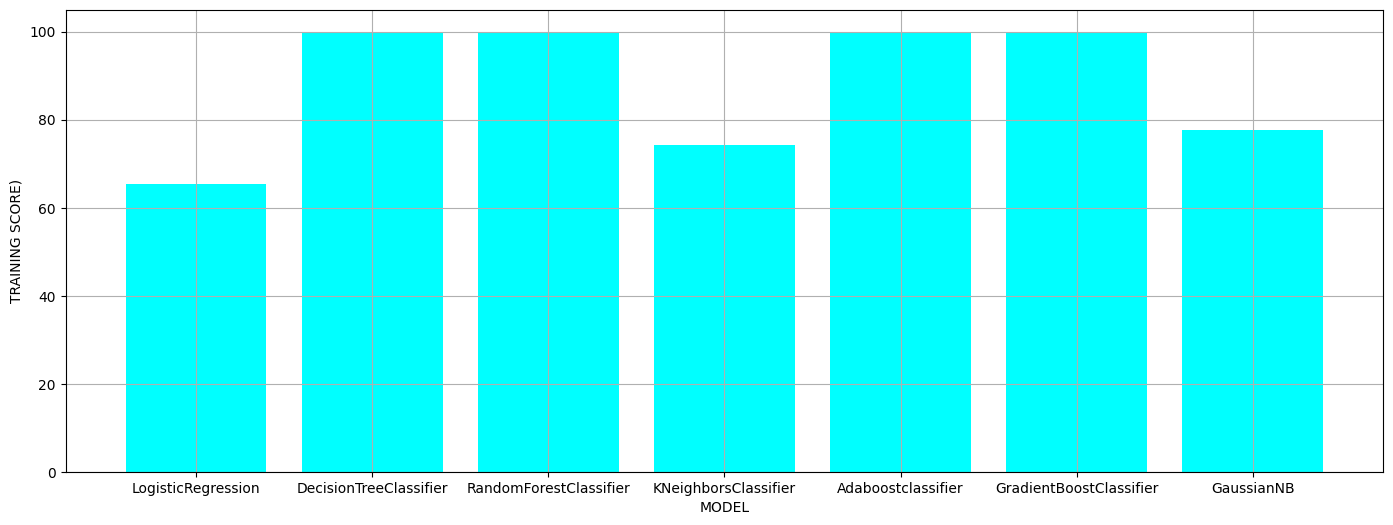

In [44]:
x=score.Model
y=score.TrainingScores
plt.figure(figsize=(17,6))
plt.bar(x,y,color="cyan")
plt.xlabel("MODEL")
plt.ylabel("TRAINING SCORE)")
plt.grid(True)
plt.show()

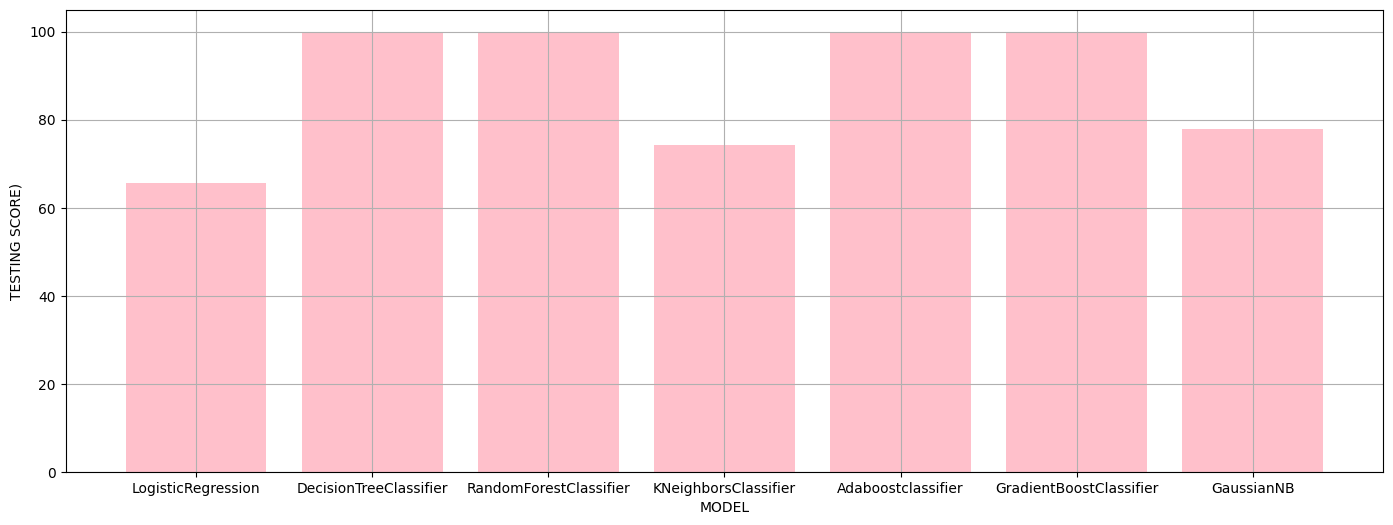

In [45]:
x=score.Model
y=score.TestingScores
plt.figure(figsize=(17,6))
plt.bar(x,y,color="pink")
plt.xlabel("MODEL")
plt.ylabel("TESTING SCORE)")
plt.grid(True)
plt.show()

# <font color="red">**BUILD GRADIO APP**</font>

In [46]:
import gradio as gr

In [48]:
def fun(Pollutant_Concentration_mg_kg, Soil_pH, Temperature_C, Humidity, Rainfall, Soil_Organic_Matter):
    input_data = np.array([[float(Pollutant_Concentration_mg_kg), float(Soil_pH), float(Temperature_C), float(Humidity), float(Rainfall), float(Soil_Organic_Matter)]])
    prediction = model.predict(input_data)
    return str(prediction[0])

headline = "SOIL QUALITY ANALYSIS"
iface = gr.Interface(
    fn=fun,
    inputs=[
        gr.Textbox(label="Pollutant_Concentration_mg_kg"),
        gr.Textbox(label="Soil_pH"),
        gr.Textbox(label="Temperature_C"),
        gr.Textbox(label="Humidity_%"),
        gr.Textbox(label="Rainfall_mm"),
        gr.Textbox(label="Soil_Organic_Matter_%")
    ],
    outputs=[gr.Textbox(label="Soil_Quality")],
    title=headline
)
iface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6648d2577b8b65efe2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
